In [2]:
import sys
sys.path.append('../1_data_extraction')

import matplotlib.pyplot as plt

from LRO_data_class import getLunarRobbinsLabels

dataLabels = getLunarRobbinsLabels()

- **Latitude:** 60°S → 60°N (SLDEM2015's cap - this is the ceiling for "whole moon", not actually pole-to-pole)
- **Longitude:** 0° → 360° (all 4 tile bins, no restriction)

In [4]:
smallLabelCraters = dataLabels[
    (dataLabels['DIAM_CIRC_IMG'] < 10) &
    (dataLabels['LAT_CIRC_IMG'] >= -60) &
    (dataLabels['LAT_CIRC_IMG'] <= 60) &
    (dataLabels['ARC_IMG'] > 0.5)
]

smallLabelCraters.to_csv('../2_data_preparation/filtered_labels_alltiles.csv', index=False)

print(f'smallLabelCraters: {smallLabelCraters.shape}')


smallLabelCraters: (1007519, 21)


In [5]:
lon_bins = [(0, 90), (90, 180), (180, 270), (270, 360)]
lat_bins = [(0, 60, 'N'), (-60, 0, 'S')]

print(f"{'tile':<28}{'craters':>10}")
for lat_min, lat_max, hemi in lat_bins:
    for lon_min, lon_max in lon_bins:
        n = len(smallLabelCraters[
            (smallLabelCraters['LAT_CIRC_IMG'] >= lat_min) & (smallLabelCraters['LAT_CIRC_IMG'] < lat_max) &
            (smallLabelCraters['LON_CIRC_IMG'] >= lon_min) & (smallLabelCraters['LON_CIRC_IMG'] < lon_max)
        ])
        name = f"E300{hemi}{int((lon_min+lon_max)/2*10):04d}_100M"
        print(f"{name:<28}{n:>10}")


tile                           craters
E300N0450_100M                   86454
E300N1350_100M                  172774
E300N2250_100M                  137010
E300N3150_100M                   64951
E300S0450_100M                  180145
E300S1350_100M                  158069
E300S2250_100M                  114126
E300S3150_100M                   93989


## Crater centres across the full band

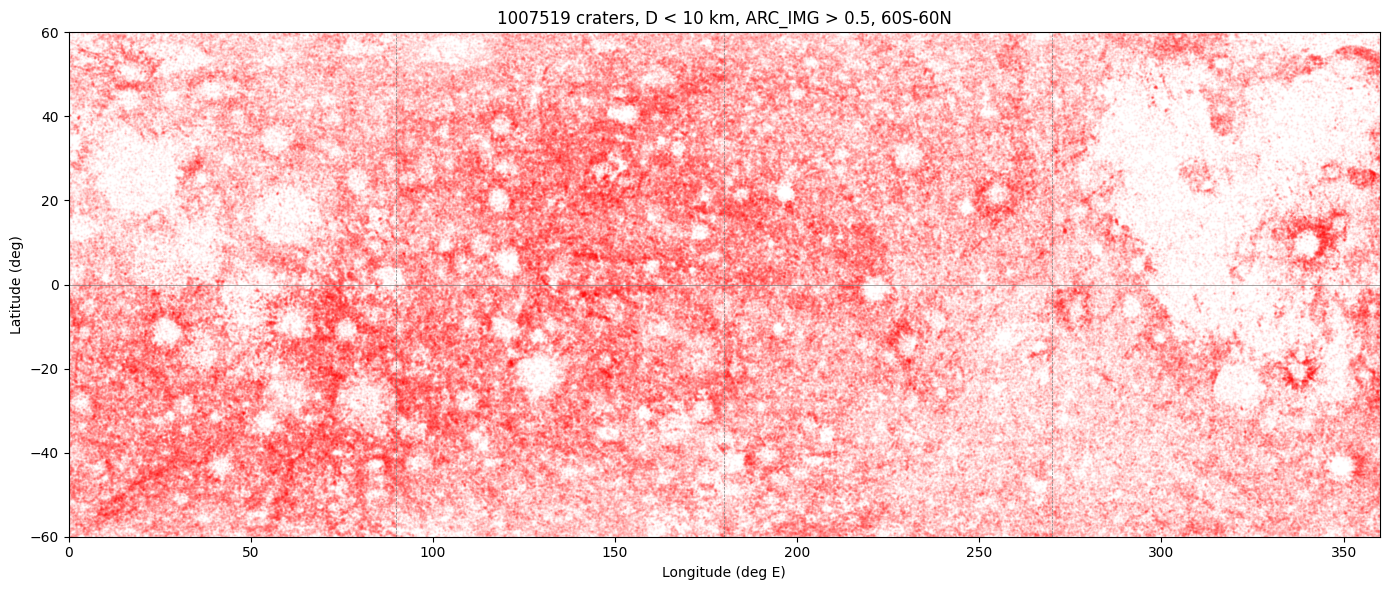

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(smallLabelCraters['LON_CIRC_IMG'], smallLabelCraters['LAT_CIRC_IMG'], s=0.3, alpha=0.05, c='red')
ax.axhline(0, color='gray', linewidth=0.5)

for x in (90, 180, 270):
    ax.axvline(x, color='gray', linewidth=0.5, linestyle='--')

ax.set_xlim(0, 360)
ax.set_ylim(-60, 60)
ax.set_xlabel('Longitude (deg E)')
ax.set_ylabel('Latitude (deg)')
ax.set_title(f'{len(smallLabelCraters)} craters, D < 10 km, ARC_IMG > 0.5, 60S-60N')

plt.tight_layout()
plt.show()
